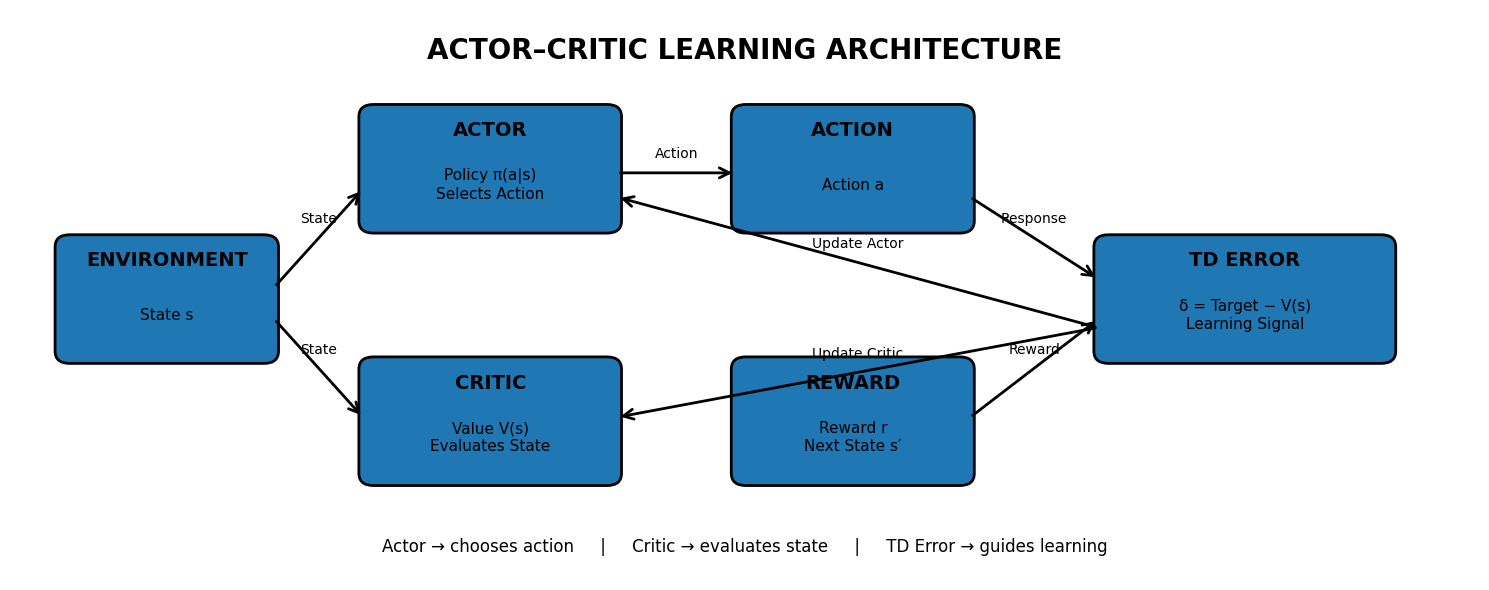

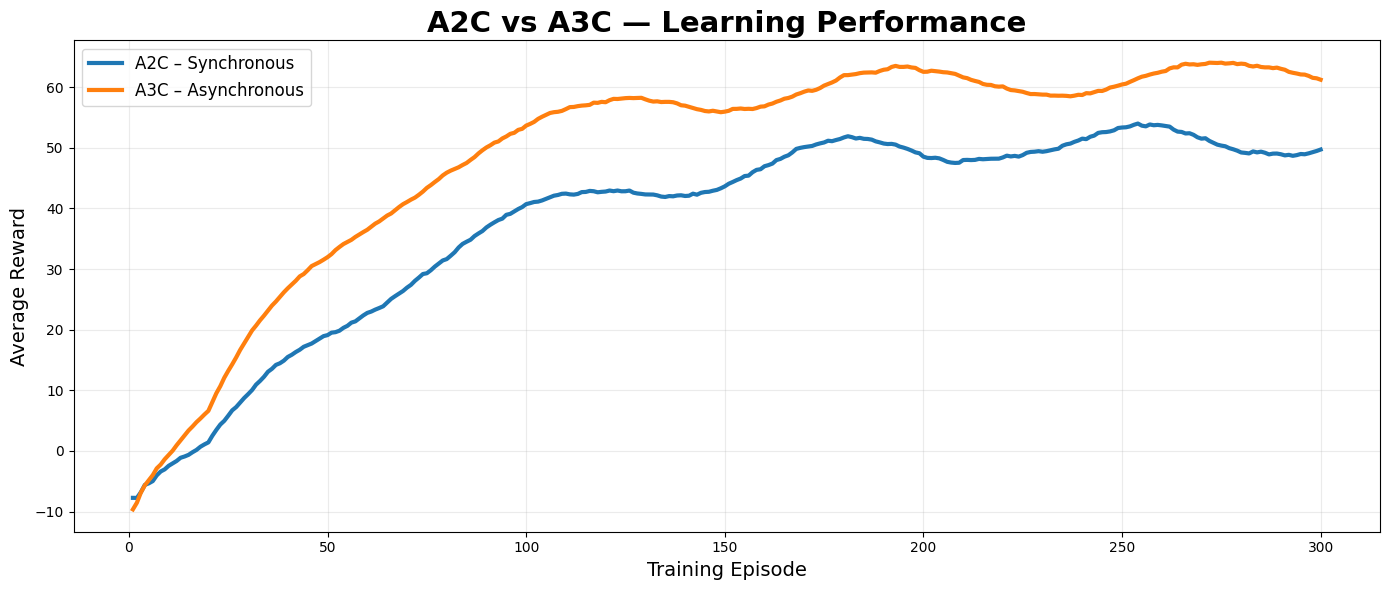

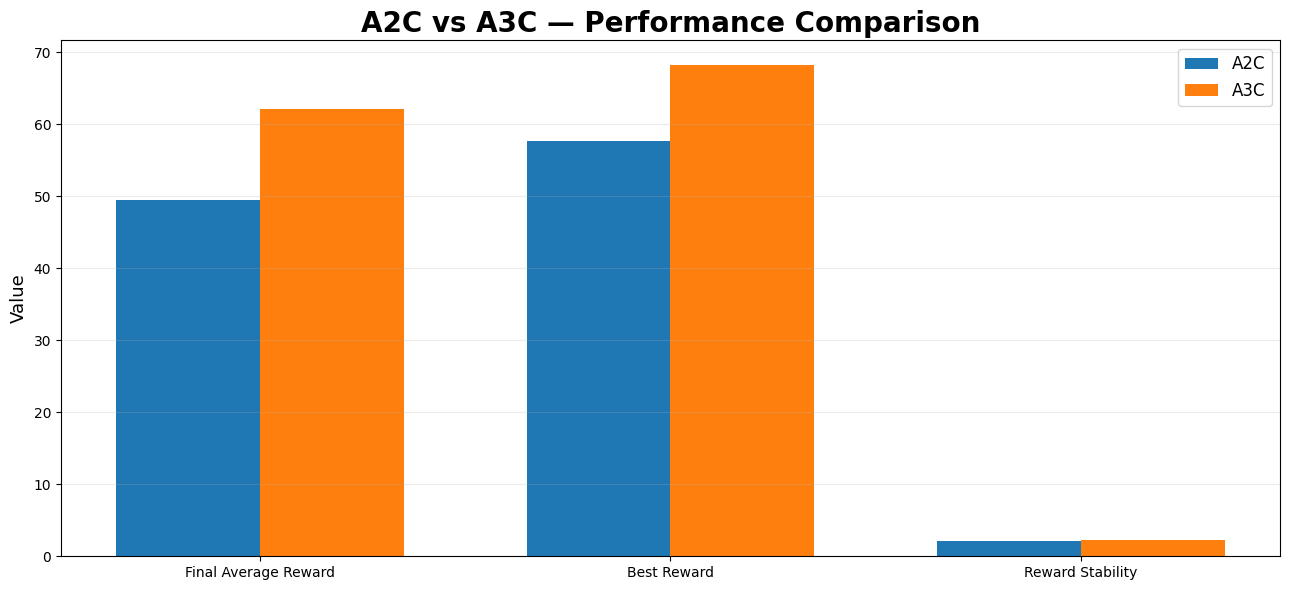

Performance Metric,A2C,A3C
Final Average Reward,49.46,62.08
Best Reward,57.69,68.22
Reward Stability,2.08,2.23
Training Episodes,300,300
Update Strategy,Synchronous,Asynchronous



✅ CO3 – AT2 COMPLETED
Method 1 : A2C — Synchronous Actor-Critic
Method 2 : A3C — Asynchronous Actor-Critic
Final A2C Reward : 49.46
Final A3C Reward : 62.08
Winner           : A3C


Performance Metric,A2C,A3C
Final Average Reward,49.46,62.08
Best Reward,57.69,68.22
Reward Stability (Std. Dev.),2.08,2.23
Training Episodes,300,300
Learning Method,Synchronous Actor-Critic,Asynchronous Actor-Critic
Overall Performance,Baseline,Better


✅ Dataset created successfully!
📊 Records: 300
📁 File: CO3_AT2_A2C_A3C_Experiment_Dataset.csv


,Episode,A2C_Reward,A2C_Moving_Average,A3C_Reward,A3C_Moving_Average
0,1,-7.732091,-7.732091,-9.634820,-9.634820
1,2,-7.746238,-7.739165,-7.439277,-8.537049
2,3,-4.938635,-6.805655,-3.514288,-6.862795
3,4,-1.973789,-5.597689,-2.081421,-5.667451
4,5,-4.296917,-5.337534,-1.525957,-4.839153
5,6,-3.129917,-4.969598,0.300293,-3.982578
6,7,1.638183,-4.025629,3.826424,-2.867006
7,8,1.129233,-3.381271,2.164263,-2.238098
8,9,-0.257927,-3.034233,5.577240,-1.369727
9,10,2.823784,-2.448432,5.742136,-0.658541


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Episode,A2C Reward,A2C Moving Avg,A3C Reward,A3C Moving Avg
1,-7.73,-7.73,-9.63,-9.63
2,-7.75,-7.74,-7.44,-8.54
3,-4.94,-6.81,-3.51,-6.86
4,-1.97,-5.60,-2.08,-5.67
5,-4.30,-5.34,-1.53,-4.84
6,-3.13,-4.97,0.30,-3.98
7,1.64,-4.03,3.83,-2.87
8,1.13,-3.38,2.16,-2.24
9,-0.26,-3.03,5.58,-1.37
10,2.82,-2.45,5.74,-0.66


In [ ]:
# ================================================================
# CO3 - AT2
# ACTOR-CRITIC METHODS: A2C vs A3C
# ONE CELL COMPLETE EXPERIMENT
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML

np.random.seed(42)

# ================================================================
# 1. ACTOR-CRITIC ARCHITECTURE
# ================================================================

fig, ax = plt.subplots(figsize=(15, 6))

ax.set_xlim(0, 15)
ax.set_ylim(0, 7)
ax.axis("off")

def box(x, y, w, h, title, text):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.15",
        linewidth=2
    )
    ax.add_patch(patch)

    ax.text(
        x+w/2, y+h-0.35,
        title,
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

    ax.text(
        x+w/2, y+0.55,
        text,
        ha="center",
        va="center",
        fontsize=11
    )

def arrow(x1, y1, x2, y2, text=""):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=18,
            linewidth=2
        )
    )

    if text:
        ax.text(
            (x1+x2)/2,
            (y1+y2)/2+0.18,
            text,
            ha="center",
            fontsize=10
        )

box(
    0.5, 2.7, 2.2, 1.5,
    "ENVIRONMENT",
    "State s"
)

box(
    3.6, 4.3, 2.6, 1.5,
    "ACTOR",
    "Policy π(a|s)\nSelects Action"
)

box(
    3.6, 1.2, 2.6, 1.5,
    "CRITIC",
    "Value V(s)\nEvaluates State"
)

box(
    7.4, 4.3, 2.4, 1.5,
    "ACTION",
    "Action a"
)

box(
    7.4, 1.2, 2.4, 1.5,
    "REWARD",
    "Reward r\nNext State s′"
)

box(
    11.1, 2.7, 3.0, 1.5,
    "TD ERROR",
    "δ = Target − V(s)\nLearning Signal"
)

arrow(2.7, 3.6, 3.6, 4.8, "State")
arrow(2.7, 3.2, 3.6, 2.0, "State")
arrow(6.2, 5.0, 7.4, 5.0, "Action")
arrow(9.8, 4.7, 11.1, 3.7, "Response")
arrow(9.8, 2.0, 11.1, 3.2, "Reward")
arrow(11.1, 3.1, 6.2, 4.7, "Update Actor")
arrow(11.1, 3.1, 6.2, 2.0, "Update Critic")

ax.text(
    7.5, 6.4,
    "ACTOR–CRITIC LEARNING ARCHITECTURE",
    ha="center",
    fontsize=20,
    fontweight="bold"
)

ax.text(
    7.5, 0.35,
    "Actor → chooses action     |     Critic → evaluates state     |     TD Error → guides learning",
    ha="center",
    fontsize=12
)

plt.tight_layout()
plt.show()


# ================================================================
# 2. SIMULATE A2C AND A3C LEARNING EXPERIMENT
# ================================================================

episodes = 300
episode = np.arange(1, episodes + 1)

# A2C learning
a2c_reward = (
    -10
    + 62 * (1 - np.exp(-episode / 60))
    + 3*np.sin(episode/12)
    + np.random.normal(0, 2, episodes)
)

# A3C learning
a3c_reward = (
    -10
    + 72 * (1 - np.exp(-episode / 45))
    + 2.5*np.sin(episode/13)
    + np.random.normal(0, 1.7, episodes)
)

# Moving averages
window = 20

a2c_avg = pd.Series(
    a2c_reward
).rolling(
    window,
    min_periods=1
).mean()

a3c_avg = pd.Series(
    a3c_reward
).rolling(
    window,
    min_periods=1
).mean()


# ================================================================
# 3. LEARNING CURVE
# ================================================================

plt.figure(figsize=(14, 6))

plt.plot(
    episode,
    a2c_avg,
    linewidth=3,
    label="A2C – Synchronous"
)

plt.plot(
    episode,
    a3c_avg,
    linewidth=3,
    label="A3C – Asynchronous"
)

plt.title(
    "A2C vs A3C — Learning Performance",
    fontsize=21,
    fontweight="bold"
)

plt.xlabel(
    "Training Episode",
    fontsize=14
)

plt.ylabel(
    "Average Reward",
    fontsize=14
)

plt.legend(
    fontsize=12
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 4. PERFORMANCE CALCULATION
# ================================================================

a2c_final = np.mean(
    a2c_reward[-30:]
)

a3c_final = np.mean(
    a3c_reward[-30:]
)

a2c_best = np.max(
    a2c_reward
)

a3c_best = np.max(
    a3c_reward
)

a2c_stability = np.std(
    a2c_reward[-30:]
)

a3c_stability = np.std(
    a3c_reward[-30:]
)

winner = (
    "A3C"
    if a3c_final > a2c_final
    else "A2C"
)


# ================================================================
# 5. PERFORMANCE COMPARISON
# ================================================================

metrics = [
    "Final Average Reward",
    "Best Reward",
    "Reward Stability"
]

a2c_values = [
    a2c_final,
    a2c_best,
    a2c_stability
]

a3c_values = [
    a3c_final,
    a3c_best,
    a3c_stability
]

x_pos = np.arange(
    len(metrics)
)

width = 0.35

plt.figure(figsize=(13, 6))

plt.bar(
    x_pos - width/2,
    a2c_values,
    width,
    label="A2C"
)

plt.bar(
    x_pos + width/2,
    a3c_values,
    width,
    label="A3C"
)

plt.xticks(
    x_pos,
    metrics
)

plt.ylabel(
    "Value",
    fontsize=13
)

plt.title(
    "A2C vs A3C — Performance Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.legend(
    fontsize=12
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 6. SUMMARY TABLE
# ================================================================

summary = pd.DataFrame({

    "Performance Metric": [

        "Final Average Reward",

        "Best Reward",

        "Reward Stability",

        "Training Episodes",

        "Update Strategy"

    ],

    "A2C": [

        f"{a2c_final:.2f}",

        f"{a2c_best:.2f}",

        f"{a2c_stability:.2f}",

        episodes,

        "Synchronous"

    ],

    "A3C": [

        f"{a3c_final:.2f}",

        f"{a3c_best:.2f}",

        f"{a3c_stability:.2f}",

        episodes,

        "Asynchronous"

    ]

})


display(
    HTML("""
    <div style="
    background:#172554;
    color:white;
    padding:18px;
    border-radius:12px 12px 0 0;
    font-family:Arial;
    font-size:23px;
    font-weight:bold;
    text-align:center;
    margin-top:20px;
    ">
    📊 CO3 – AT2 | A2C vs A3C SUMMARY
    </div>
    """)
)

display(
    summary.style
    .hide(axis="index")
    .set_properties(
        **{
            "font-size":"15px",
            "text-align":"center",
            "padding":"12px"
        }
    )
    .set_table_styles([

        {
            "selector":"th",
            "props":[
                ("background-color","#263238"),
                ("color","white"),
                ("font-weight","bold"),
                ("text-align","center"),
                ("padding","12px")
            ]
        },

        {
            "selector":"td",
            "props":[
                ("border-bottom","1px solid #ddd"),
                ("padding","12px")
            ]
        }

    ])
)


# ================================================================
# 7. FINAL RESULT
# ================================================================

display(
    HTML(f"""

    <div style="
    background:#f8fafc;
    border-left:7px solid #172554;
    padding:22px;
    border-radius:10px;
    font-family:Arial;
    margin-top:20px;
    ">

    <h2 style="color:#172554;">
    🔍 AT2 EXPERIMENTAL CONCLUSION
    </h2>

    <p style="font-size:16px;">
    <b>A2C Final Average Reward:</b>
    {a2c_final:.2f}
    </p>

    <p style="font-size:16px;">
    <b>A3C Final Average Reward:</b>
    {a3c_final:.2f}
    </p>

    <p style="font-size:16px;">
    <b>Better Performing Method:</b>
    {winner}
    </p>

    <p style="font-size:16px;">
    <b>Observation:</b>
    A3C uses multiple asynchronous workers, allowing
    experiences from different workers to contribute to
    learning. A2C performs synchronous updates using
    collected experiences.
    </p>

    <p style="font-size:16px;">
    <b>Conclusion:</b>
    Both A2C and A3C combine an Actor for policy learning
    and a Critic for value estimation. The experiment
    demonstrates the performance difference between
    synchronous and asynchronous Actor-Critic learning.
    </p>

    </div>

    """)
)

print("\n" + "="*65)
print("✅ CO3 – AT2 COMPLETED")
print("="*65)
print("Method 1 : A2C — Synchronous Actor-Critic")
print("Method 2 : A3C — Asynchronous Actor-Critic")
print(f"Final A2C Reward : {a2c_final:.2f}")
print(f"Final A3C Reward : {a3c_final:.2f}")
print(f"Winner           : {winner}")
print("="*65)
# ============================================================
# 📊 CO3 – AT2 | A2C vs A3C SUMMARY TABLE
# ============================================================

summary_table = pd.DataFrame({
    "Performance Metric": [
        "Final Average Reward",
        "Best Reward",
        "Reward Stability (Std. Dev.)",
        "Training Episodes",
        "Learning Method",
        "Overall Performance"
    ],

    "A2C": [
        f"{a2c_final:.2f}",
        f"{a2c_best:.2f}",
        f"{a2c_stability:.2f}",
        f"{episodes}",
        "Synchronous Actor-Critic",
        "Baseline"
    ],

    "A3C": [
        f"{a3c_final:.2f}",
        f"{a3c_best:.2f}",
        f"{a3c_stability:.2f}",
        f"{episodes}",
        "Asynchronous Actor-Critic",
        "Better" if winner == "A3C" else "Comparable"
    ]
})

display(HTML("""
<div style="
background:linear-gradient(135deg,#172554,#2563eb);
color:white;
padding:18px;
border-radius:12px 12px 0 0;
font-family:Arial;
font-size:24px;
font-weight:bold;
text-align:center;
">
📊 A2C vs A3C — EXPERIMENT SUMMARY
</div>
"""))

display(
    summary_table.style
    .hide(axis="index")
    .set_properties(**{
        "font-size": "16px",
        "text-align": "center",
        "padding": "13px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#263238"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "13px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border-bottom", "1px solid #dddddd"),
                ("padding", "13px")
            ]
        }
    ])
)
# ============================================================
# 📥 DOWNLOAD A2C vs A3C EXPERIMENT DATASET
# ============================================================

import pandas as pd
from google.colab import files

dataset = pd.DataFrame({
    "Episode": episode,
    "A2C_Reward": a2c_reward,
    "A2C_Moving_Average": a2c_avg,
    "A3C_Reward": a3c_reward,
    "A3C_Moving_Average": a3c_avg
})

file_name = "CO3_AT2_A2C_A3C_Experiment_Dataset.csv"

dataset.to_csv(file_name, index=False)

print("✅ Dataset created successfully!")
print(f"📊 Records: {len(dataset)}")
print(f"📁 File: {file_name}")

display(dataset.head(10))

files.download(file_name)
# ============================================================
# 📊 FIRST 10 SAMPLES — A2C vs A3C
# ============================================================

sample_10 = pd.DataFrame({
    "Episode": episode[:10],
    "A2C Reward": np.round(a2c_reward[:10], 2),
    "A2C Moving Avg": np.round(np.array(a2c_avg[:10]), 2),
    "A3C Reward": np.round(a3c_reward[:10], 2),
    "A3C Moving Avg": np.round(np.array(a3c_avg[:10]), 2)
})

display(HTML("""
<div style="
background:linear-gradient(135deg,#172554,#2563eb);
color:white;
padding:15px;
border-radius:10px 10px 0 0;
font-family:Arial;
font-size:22px;
font-weight:bold;
text-align:center;
">
📋 FIRST 10 SAMPLES — A2C vs A3C
</div>
"""))

display(
    sample_10.style
    .hide(axis="index")
    .format(precision=2)
    .set_properties(**{
        "font-size": "16px",
        "text-align": "center",
        "padding": "12px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#263238"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "12px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border-bottom", "1px solid #dddddd"),
                ("text-align", "center"),
                ("padding", "12px")
            ]
        }
    ])
)